In [ ]:
## Carga de datos
import pandas as pd
import numpy as np
data_frame = pd.read_csv("/content/insurance.csv")
data_frame

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [1]:
data_frame.info()


NameError: name 'data_frame' is not defined

In [3]:
# Tipos de datos de las columnas
data_frame.dtypes

NameError: name 'data_frame' is not defined

In [2]:
data_frame['sex']=data_frame['sex'].astype('category')
data_frame['sex']=data_frame['sex'].cat.codes
data_frame['smoker']=data_frame['smoker'].astype('category')
data_frame['smoker']=data_frame['smoker'].cat.codes
data_frame['region']=data_frame['region'].astype('category')
data_frame['region']=data_frame['region'].cat.codes



NameError: name 'data_frame' is not defined

<Axes: title={'center': 'Pearson Correlation of Features'}>

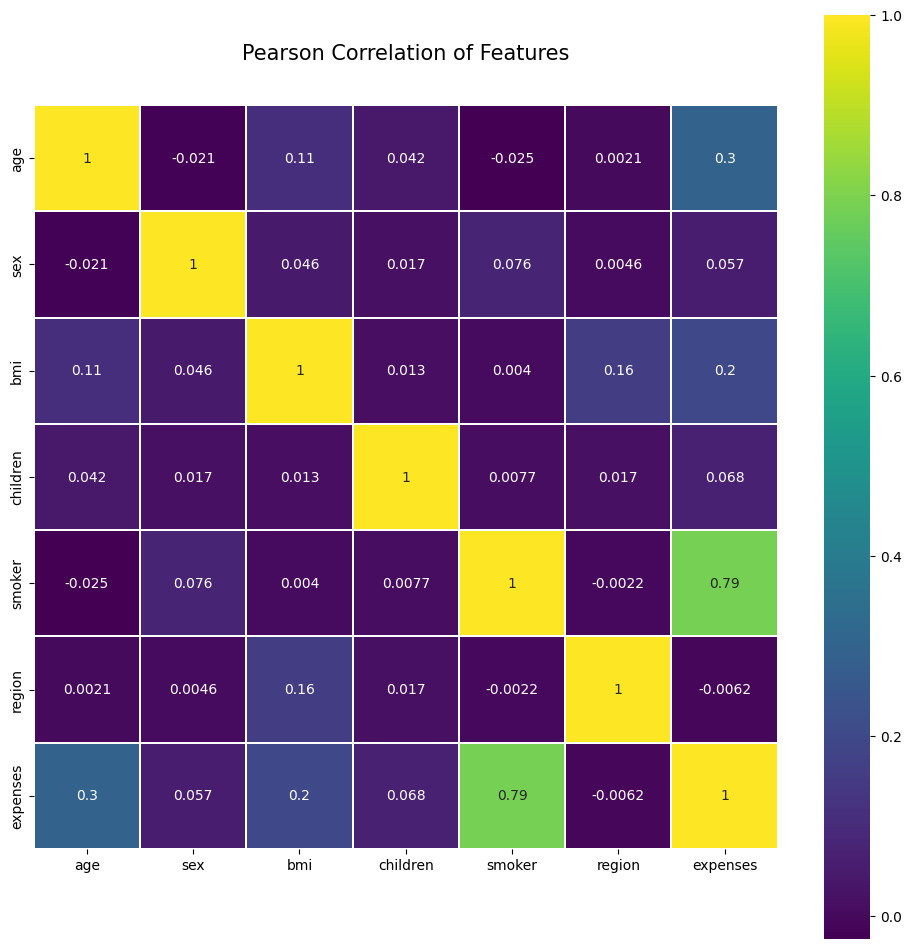

In [ ]:
import seaborn as sb
colormap = plt.cm.viridis
plt.figure(figsize=(12,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sb.heatmap(data_frame.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)

In [ ]:
data_frame.describe()

,age,sex,bmi,children,smoker,region,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.665471,1.094918,0.204783,1.515695,13270.422414
std,14.049960,0.500160,6.098382,1.205493,0.403694,1.104885,12110.011240
min,18.000000,0.000000,16.000000,0.000000,0.000000,0.000000,1121.870000
25%,27.000000,0.000000,26.300000,0.000000,0.000000,1.000000,4740.287500
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.030000
75%,51.000000,1.000000,34.700000,2.000000,0.000000,2.000000,16639.915000
max,64.000000,1.000000,53.100000,5.000000,1.000000,3.000000,63770.430000


In [ ]:
print(data_frame.groupby('smoker').size())

smoker
0    1064
1     274
dtype: int64


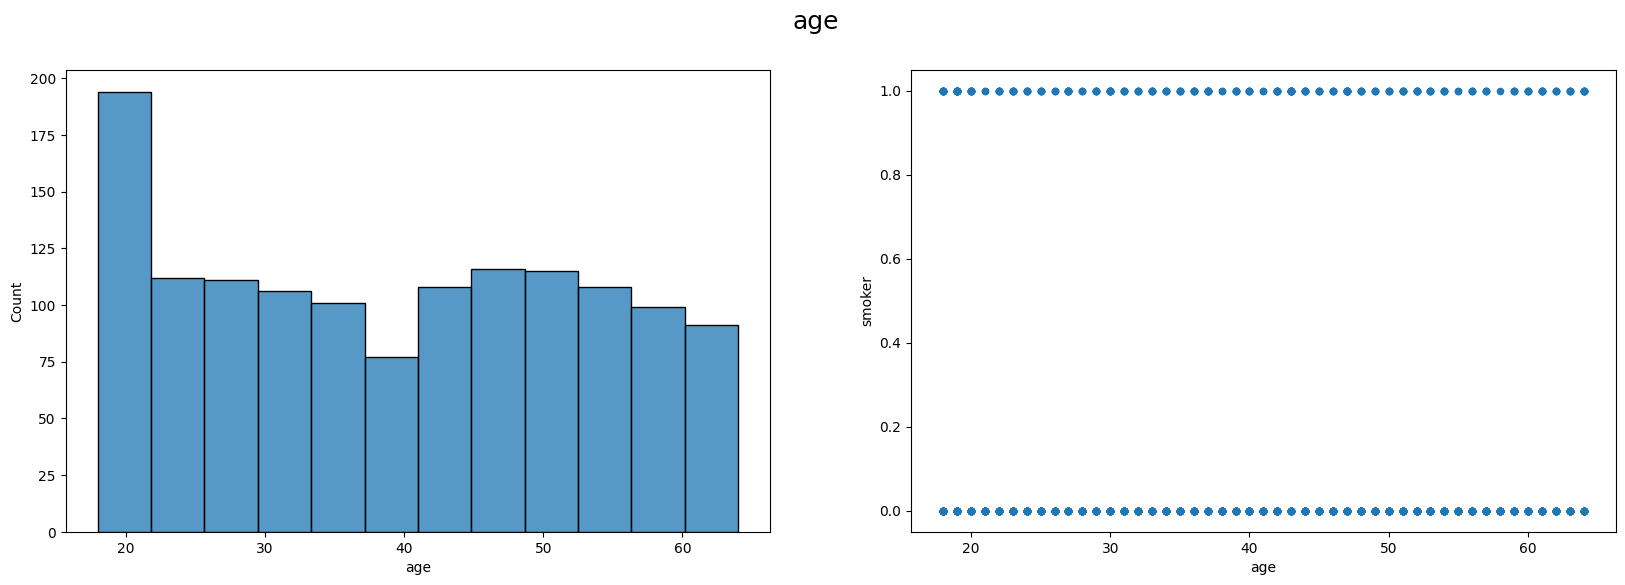

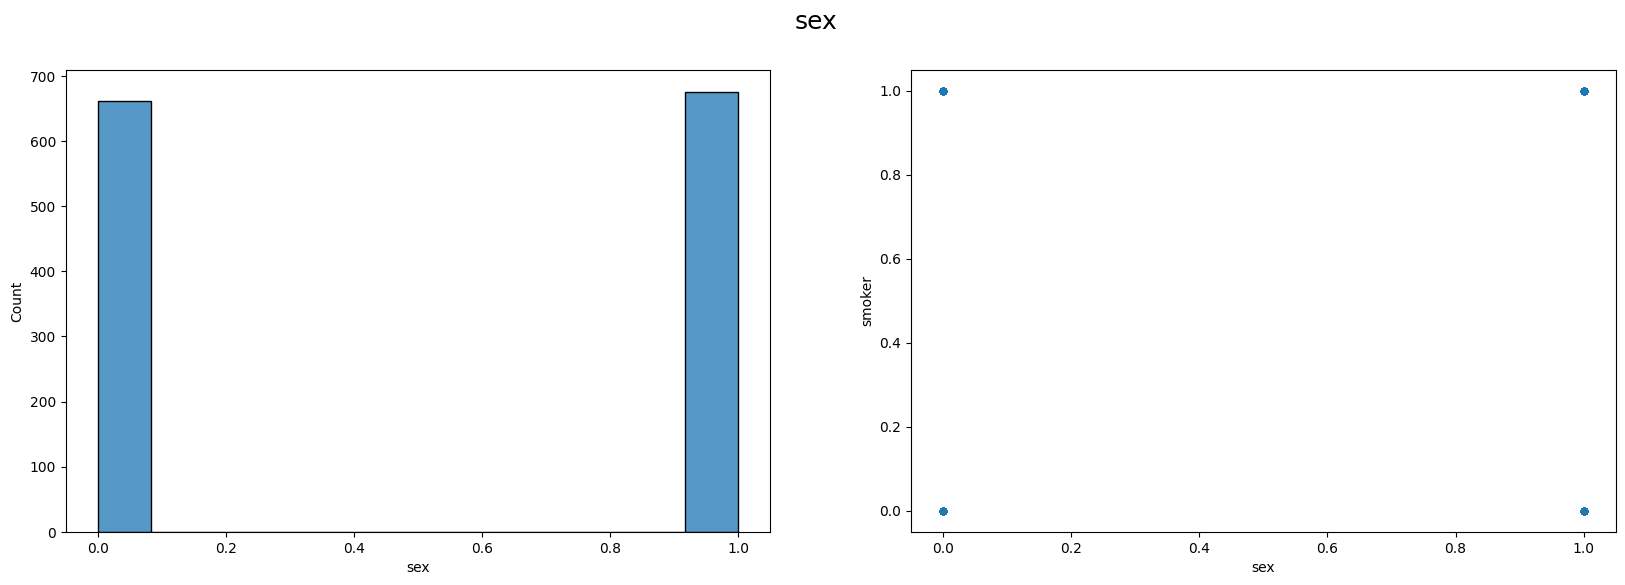

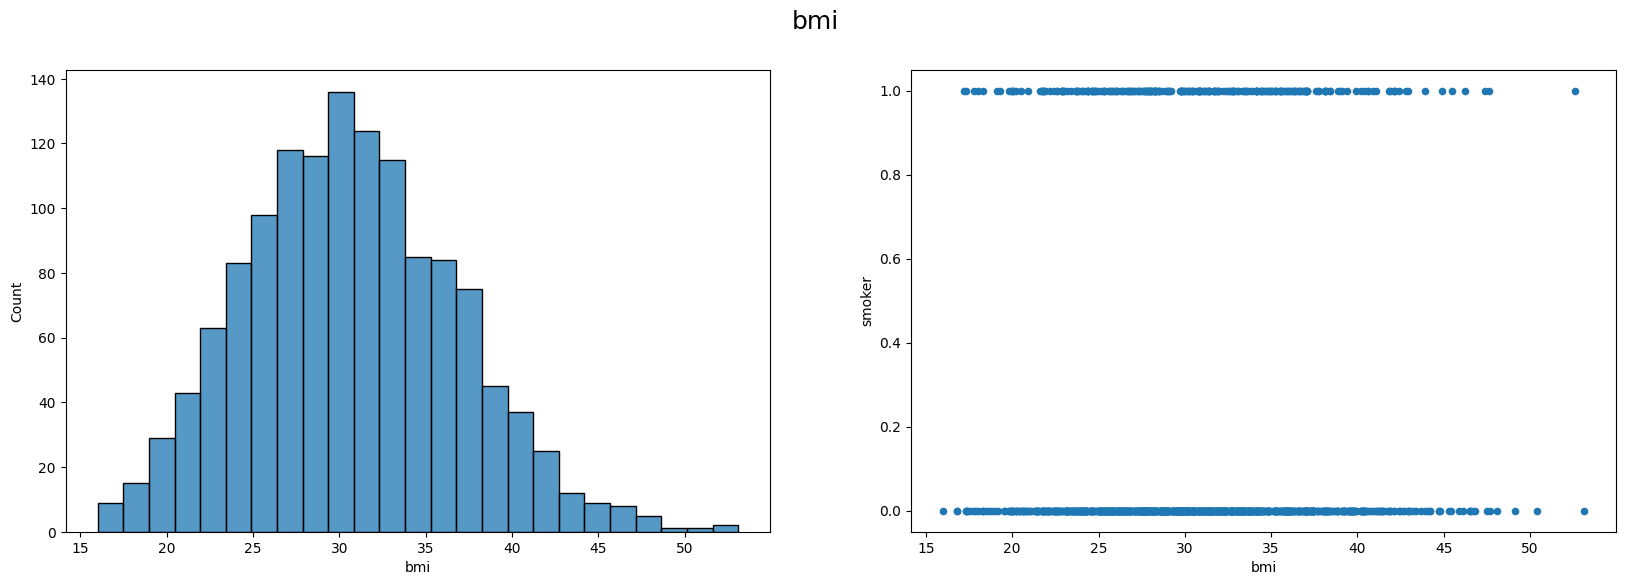

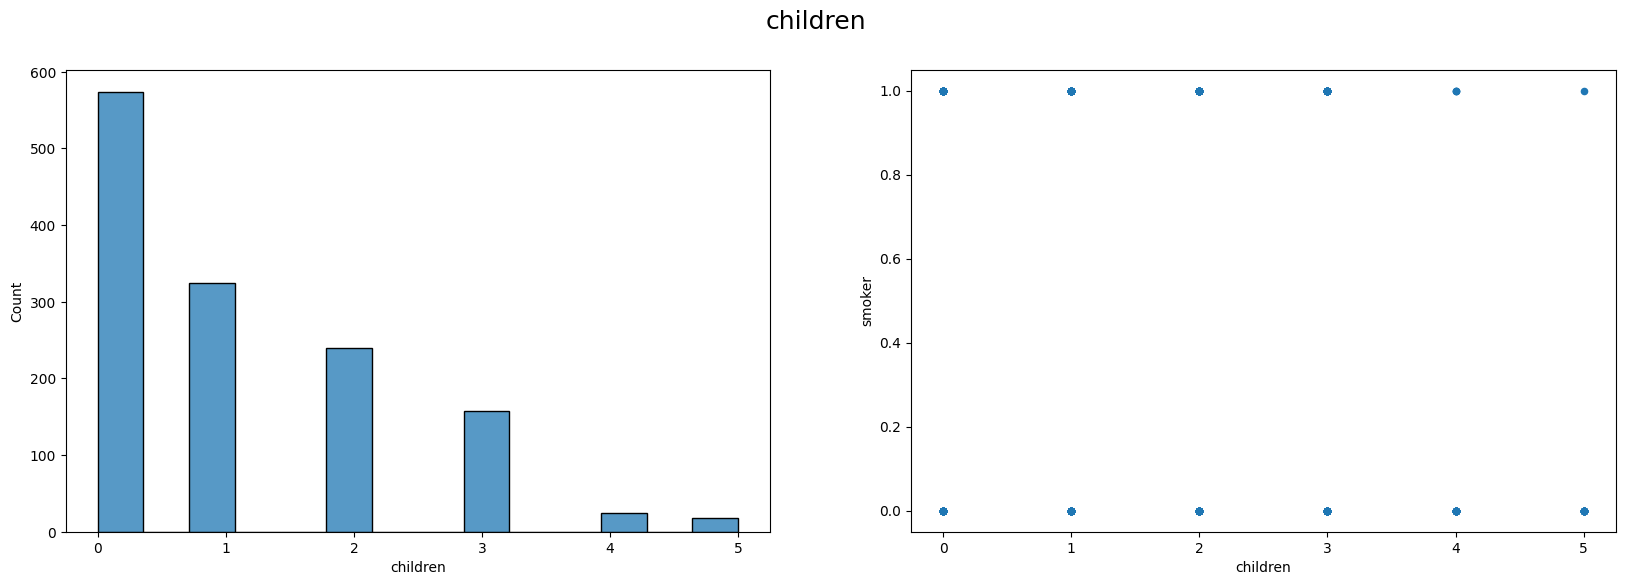

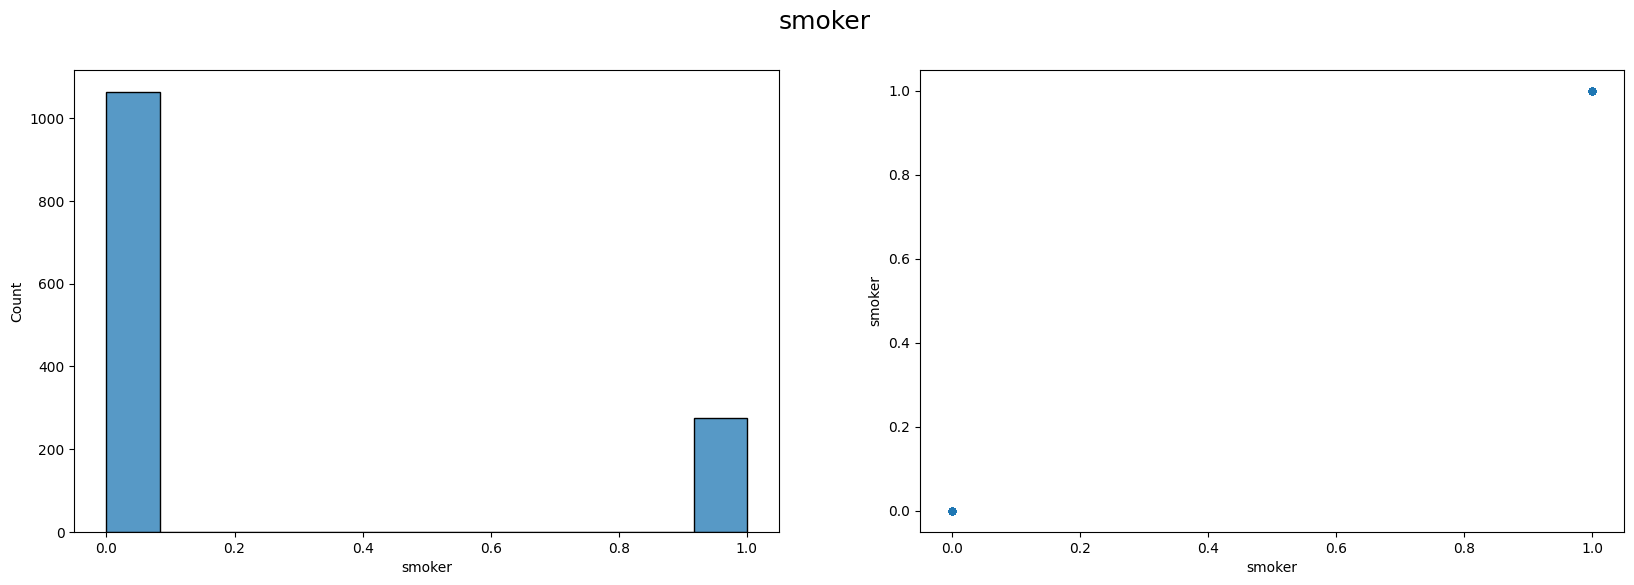

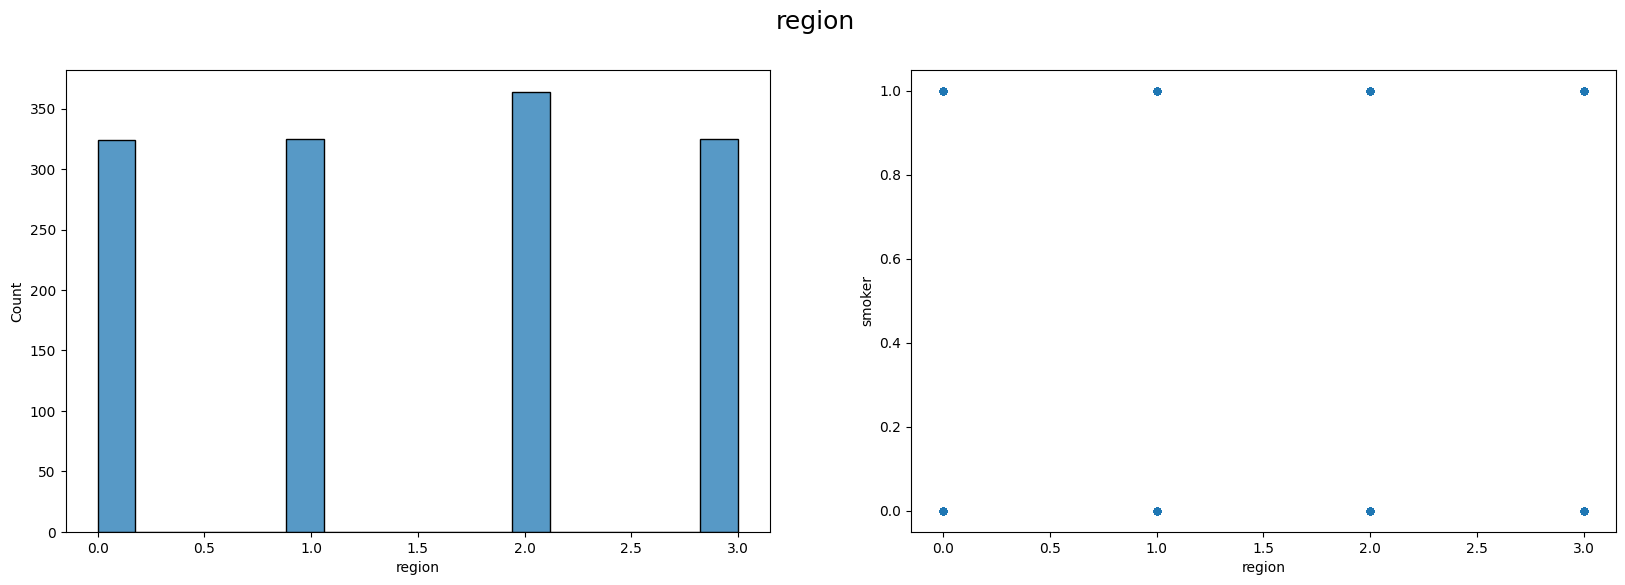

In [ ]:
import seaborn as sns
columnas = np.array(data_frame.columns)
for col in columnas[:-1]:
  fig, ax =plt.subplots(1, 2, figsize=(20, 6))
  fig.suptitle(col, fontsize=18)
  sns.histplot(data_frame[col], ax=ax[0], kde=False)
  data_frame[[col]+['smoker']].plot.scatter(x=col, y='smoker', ax=ax[1])
  plt.show()

In [4]:
#paso 1
# Selecciona las variables
X = data_frame.drop('smoker', axis=1)  # X=data_frame[[""," "," "]]
# Rescata la etiqueta
y = data_frame.smoker

NameError: name 'data_frame' is not defined

In [ ]:
#paso 2
from sklearn.model_selection import train_test_split
# Se separan los datos de "train" en entrenamiento y prueba para probar losalgoritmos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state = 29)

#paso 3
# Define el algoritmo a utilizar Naive Bayes
from sklearn.naive_bayes import GaussianNB
modelo = GaussianNB()
#paso 4
# Entrenamiento del modelo
modelo.fit(X_train, y_train)
#paso 5
# Validación del modelo
y_pred = modelo.predict(X_test)

In [ ]:
# Evaluación del modelo
from sklearn.metrics import accuracy_score, f1_score, recall_score
matriz_x = confusion_matrix(y_test, y_pred)
print('Matriz de Confusión:')
print(matriz_x)
accuracy = accuracy_score(y_test, y_pred)
print('Accurancy del modelo:',accuracy)
print('F1 score del modelo:',f1_score(y_test, y_pred))
print('Recall del modelo:',recall_score(y_test, y_pred))

Matriz de Confusión:
[[184  16]
 [ 23  45]]
Accurancy del modelo: 0.8544776119402985
F1 score del modelo: 0.6976744186046512
Recall del modelo: 0.6617647058823529


In [ ]:
#Mejoramos el modelo seleccionando las mejores variables
from sklearn.feature_selection import SelectKBest
X=data_frame.drop('smoker', axis=1)
y=data_frame['smoker']
best=SelectKBest(k=4)
X_new = best.fit_transform(X, y)
X_new.shape
selected = best.get_support(indices=True)
print(X.columns[selected])

Index(['age', 'sex', 'children', 'expenses'], dtype='object')


<Axes: title={'center': 'Pearson Correlation of Features'}>

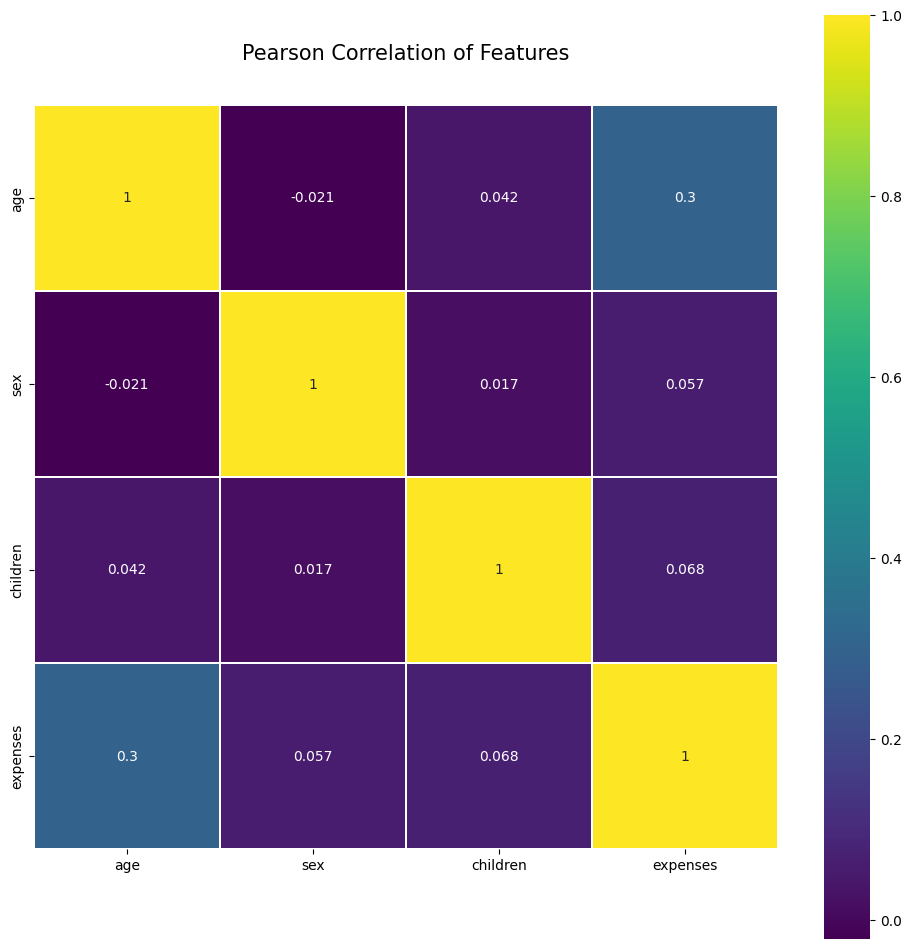

In [ ]:
import seaborn as sb
used_features =X.columns[selected]
colormap = plt.cm.viridis
plt.figure(figsize=(12,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sb.heatmap(data_frame[used_features].astype(float).corr(),linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)

In [ ]:
X = data_frame[used_features]
# Se separan los datos de "train" en entrenamiento y prueba para probar los algoritmos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state = 29)
modelo_x = GaussianNB()
# Entrenamiento del modelo
modelo_x.fit(X_train, y_train)
# Validación del modelo
y_pred = modelo_x.predict(X_test)

In [ ]:
# Evaluación del modelo
matriz_x = confusion_matrix(y_test, y_pred)
print('Matriz de Confusión:')
print(matriz_x)
precision = precision_score(y_test, y_pred)
print('Precisión del modelo:')
print(precision)
recall = recall_score(y_test, y_pred)
print('Recall del modelo:')
print(recall)
print('F1 score del modelo:',f1_score(y_test, y_pred))

Matriz de Confusión:
[[184  16]
 [ 24  44]]
Precisión del modelo:
0.7333333333333333
Recall del modelo:
0.6470588235294118
F1 score del modelo: 0.6875


Ejemplo con dataset acorde al modelo

In [ ]:
df = pd.read_csv("/content/diamonds.csv")
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df1=df.drop(['color','Unnamed: 0','clarity'], axis=1)
df1

,carat,cut,depth,table,price,x,y,z
0,0.23,Ideal,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,61.0,58.0,2757,6.15,6.12,3.74


In [ ]:
df1['cut']=df1['cut'].astype('category')
df1['cut']=df1['cut'].cat.codes
df1

,carat,cut,depth,table,price,x,y,z
0,0.23,2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...
53935,0.72,2,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,4,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,3,61.0,58.0,2757,6.15,6.12,3.74


<Axes: title={'center': 'Pearson Correlation of Features'}>

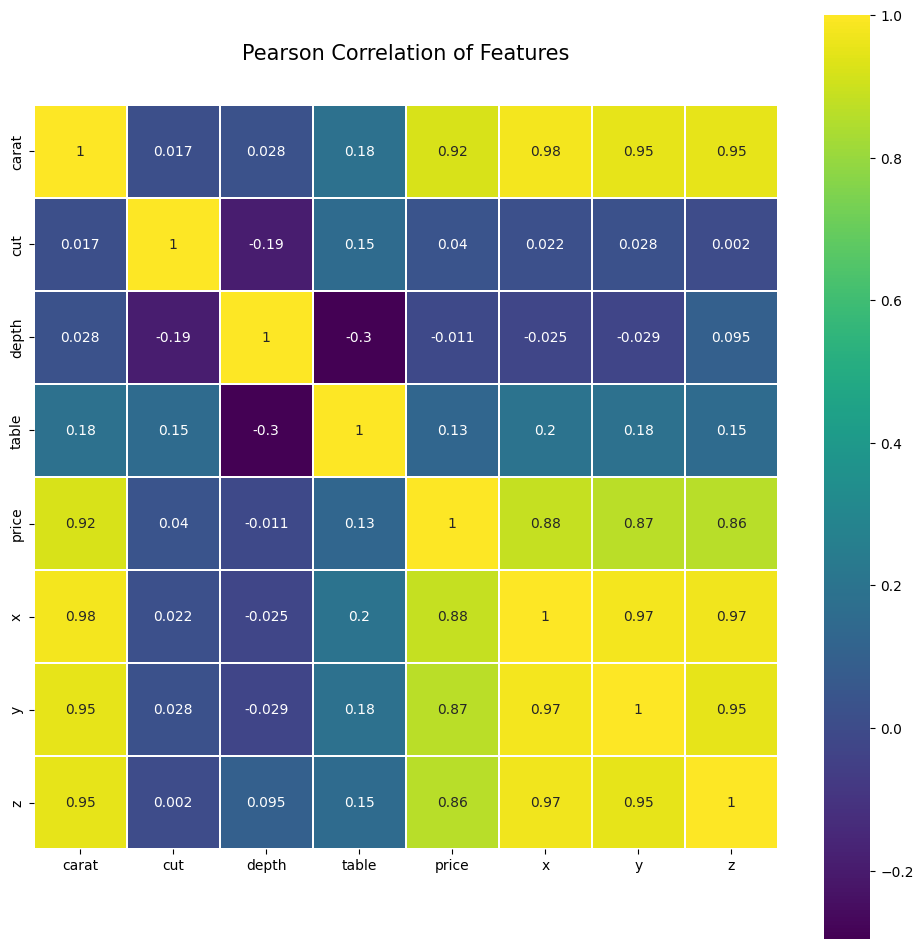

In [ ]:
import seaborn as sb
used_features =X.columns[selected]
colormap = plt.cm.viridis
plt.figure(figsize=(12,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sb.heatmap(df1.astype(float).corr(),linewidths=0.1,vmax=1.0, square=True, cmap=colormap, linecolor='white', annot=True)

In [ ]:
#Seleccionamos las variables
X=df1.drop('cut', axis=1)
y=df1['cut']

In [ ]:
# Se separan los datos de "train" en entrenamiento y prueba para probar los algoritmos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state = 29)
modelo_x = GaussianNB()
# Entrenamiento del modelo
modelo_x.fit(X_train, y_train)
# Validación del modelo
y_pred = modelo_x.predict(X_test)

In [ ]:
# Evaluación del modelo
matriz_x = confusion_matrix(y_test, y_pred)
print('Matriz de Confusión:')
print(matriz_x)
precision = precision_score(y_test, y_pred)
print('Precisión del modelo:')
print(precision)
recall = recall_score(y_test, y_pred)
print('Recall del modelo:')
print(recall)
print('F1 score del modelo:',f1_score(y_test, y_pred))

Matriz de Confusión:
[[184  16]
 [ 23  45]]
Precisión del modelo:
0.7377049180327869
Recall del modelo:
0.6617647058823529
F1 score del modelo: 0.6976744186046512
